In [1]:
snnapdatapath = "/media/udickman/uri-external-drive/SNNAP_data/fig7"
excelpath = "../Excel_files"
figpath = "../figs"
fig_prefix = "Dickman_etal_Results"
excelfile = "fig7.xlsx"

# Run this cell, then comment out the lines below and restart the kernel.
# import os
# !yes | neuronpyxl -f gen_mods --file {os.path.join(excelpath,excelfile)}

In [2]:
import sys
import os
sys.path.append("../")
import pandas as pd
import scienceplots
import matplotlib.pyplot as plt
import numpy as np
import subprocess
from neuronpyxl import network
from scipy.interpolate import griddata
plt.style.use(["no-latex", "notebook"])

snnap_data = pd.read_csv(os.path.join(snnapdatapath,"synapse.smu.out"), sep="\t").dropna(axis=1)
snnap_data.columns = ["t", "V_A", "nai_A", "V_B", "nai_B", "V_C", "nai_C"]
tsnnap = np.asarray(snnap_data["t"])

In [3]:
nb = network.NetworkBuilder(params_file=os.path.join(excelpath, excelfile), sim_name="synapse",
                            noise=None,dt=-1,integrator=2,atol=1e-5,eq_time=5000,simdur=13000,seed=False)

nb.run(voltage_only=True)

A = nb.get_cell_data("A")
B = nb.get_cell_data("B")
C = nb.get_cell_data("C")
t = np.array(A["t"]) / 1000

Added Cell(gid=1, name=A) to the network.
Added Cell(gid=2, name=B) to the network.
Added Cell(gid=3, name=C) to the network.
Loading simulation parameters...
Running simulation...


In [4]:
def remove_axes(ax,remove_x=True,remove_y=False):
    # For aesthetics
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if remove_x:
        ax.spines['bottom'].set_visible(False)
        ax.set_xticks([])
    if remove_y:
        ax.spines['left'].set_visible(False)
        ax.set_yticks([])
        
def plot_vertical_scalebar(ax,scalebar_length=20,bar_width=0.25,offset=0,xoffset=1,yoffset=10):
    from matplotlib.patches import Rectangle
    # Get axis limits
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Coordinates for bottom-right corner
    x_start = xlim[1] - offset - bar_width
    y_start = ylim[0] + offset + yoffset

    scalebar = Rectangle((x_start, y_start), width=bar_width, height=scalebar_length,
                        color='black', linewidth=0, zorder=10)

    ax.add_patch(scalebar)

    # Optional: Add text label
    ax.text(x_start-xoffset, y_start + scalebar_length / 2, f'{scalebar_length} mV',
            va='center', ha='right', color='black', fontsize=16)

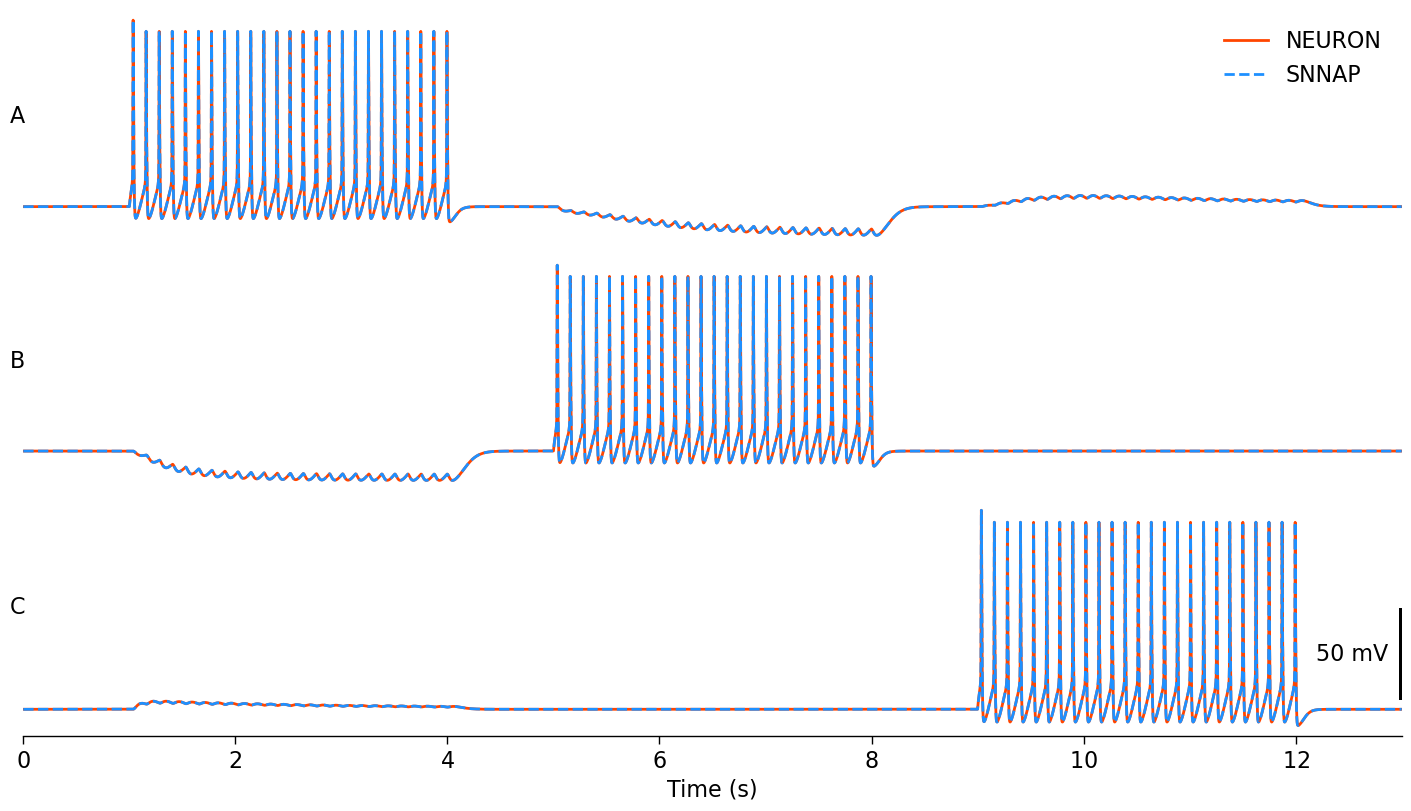

In [5]:
colors = ["red", "teal", "orchid"]
snnapcolor = "dodgerblue"
nrncolor = "orangered"
fig, ax = plt.subplots(3, 1, figsize=(14,8),constrained_layout=True)
ax[0].plot(t, A["V"], color=nrncolor,label="NEURON")
ax[0].plot(tsnnap, snnap_data["V_A"], label="SNNAP", color=snnapcolor,linestyle="--")
ax[0].set_ylabel("A",rotation=0)
ax[0].legend(frameon=False)

ax[1].plot(t, B["V"],color=nrncolor)
ax[1].plot(tsnnap, snnap_data["V_B"], color=snnapcolor,linestyle="--")
ax[1].set_ylabel("B",rotation=0)

ax[2].plot(t, C["V"],color=nrncolor)
ax[2].plot(tsnnap, snnap_data["V_C"], color=snnapcolor,linestyle="--")
ax[2].set_ylabel("C",rotation=0)

ax[2].set_xlabel("Time (s)")
ax[2].set_xticks(np.arange(0,14,step=2,dtype=int))

for a in ax:
    a.set_xlim((0,13))

remove_axes(ax[0],remove_x=True,remove_y=True)
remove_axes(ax[1],remove_x=True,remove_y=True)
remove_axes(ax[2],remove_x=False,remove_y=True)

plot_vertical_scalebar(ax[2],scalebar_length=50,bar_width=0.025,xoffset=0.1,yoffset=20)

# plt.tight_layout(pad=2.0, w_pad=0.5, h_pad=0.5)
fig.savefig(os.path.join(figpath,f"{fig_prefix}_network_plast.jpg"), bbox_inches="tight",dpi=300)